# Seeded PA VAE experiments

In [1]:
from svae import PROFILES, generators_from_run, train
from svae.evaluate import (
    graph_samples_experiment,
    graph_statistics_experiment,
    reconstruction_experiment,
    timing_experiment,
    structural_invariants_experiment
)

config = PROFILES["large"]

In [2]:
config

Config(profile='large', num_nodes=64, latent_dim=128, hidden=512, train_graphs=32768, val_graphs=4096, test_graphs=4096, generated_graphs=2048, batch_size=256, epochs=100, lr=0.001, beta=1.0, warmup_epochs=15, init_seed=20260909, threads=8)

{'train': (32768, 64), 'validation': (4096, 64), 'test': (4096, 64)}


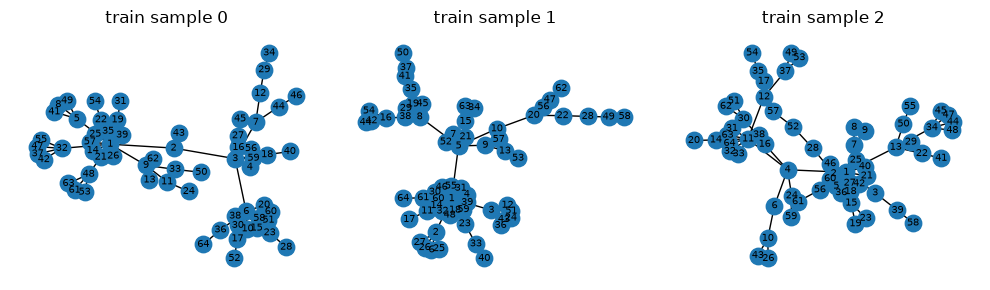

{'epoch': 1.0, 'beta': 0.06666666666666667, 'train_recon_query': 3.010803332251887, 'train_kl_graph': 8.819469200330786, 'val_recon_query': 2.9468063539074314, 'val_kl_graph': 15.759353935718536}
{'epoch': 2.0, 'beta': 0.13333333333333333, 'train_recon_query': 2.941084704091472, 'train_kl_graph': 11.386589206755161, 'val_recon_query': 2.9159947518379457, 'val_kl_graph': 12.68079799413681}
{'epoch': 3.0, 'beta': 0.2, 'train_recon_query': 2.9035259389108226, 'train_kl_graph': 10.898313000798225, 'val_recon_query': 2.8851327127025974, 'val_kl_graph': 11.3160160779953}
{'epoch': 4.0, 'beta': 0.26666666666666666, 'train_recon_query': 2.8818540803847776, 'train_kl_graph': 9.996987529098988, 'val_recon_query': 2.8648928980673514, 'val_kl_graph': 10.556033313274384}
{'epoch': 5.0, 'beta': 0.3333333333333333, 'train_recon_query': 2.8627029195908578, 'train_kl_graph': 9.932871498167515, 'val_recon_query': 2.8503447040434806, 'val_kl_graph': 10.581206500530243}
{'epoch': 6.0, 'beta': 0.4, 'train_

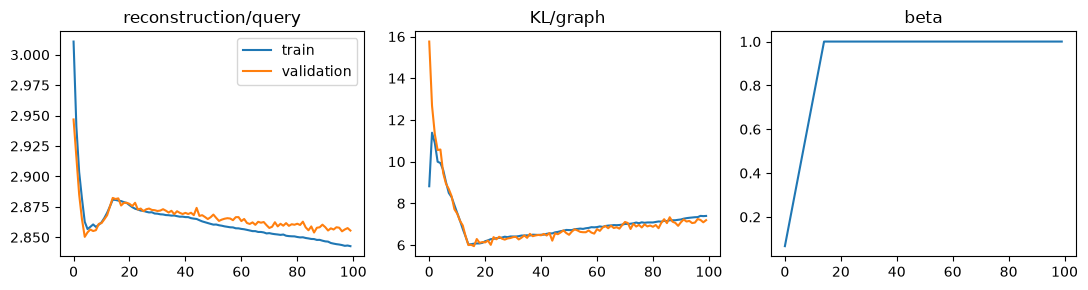

In [3]:
run = train(config)

In [4]:
generators = generators_from_run(run)

In [5]:
reconstruction = reconstruction_experiment(run)

{'mean_latent_test_parent_accuracy': 0.23059868812561035, 'mean_latent_test_cross_entropy': 2.7982044219970703, 'note': 'reconstruction diagnostic; not fresh generation or marginal likelihood'}


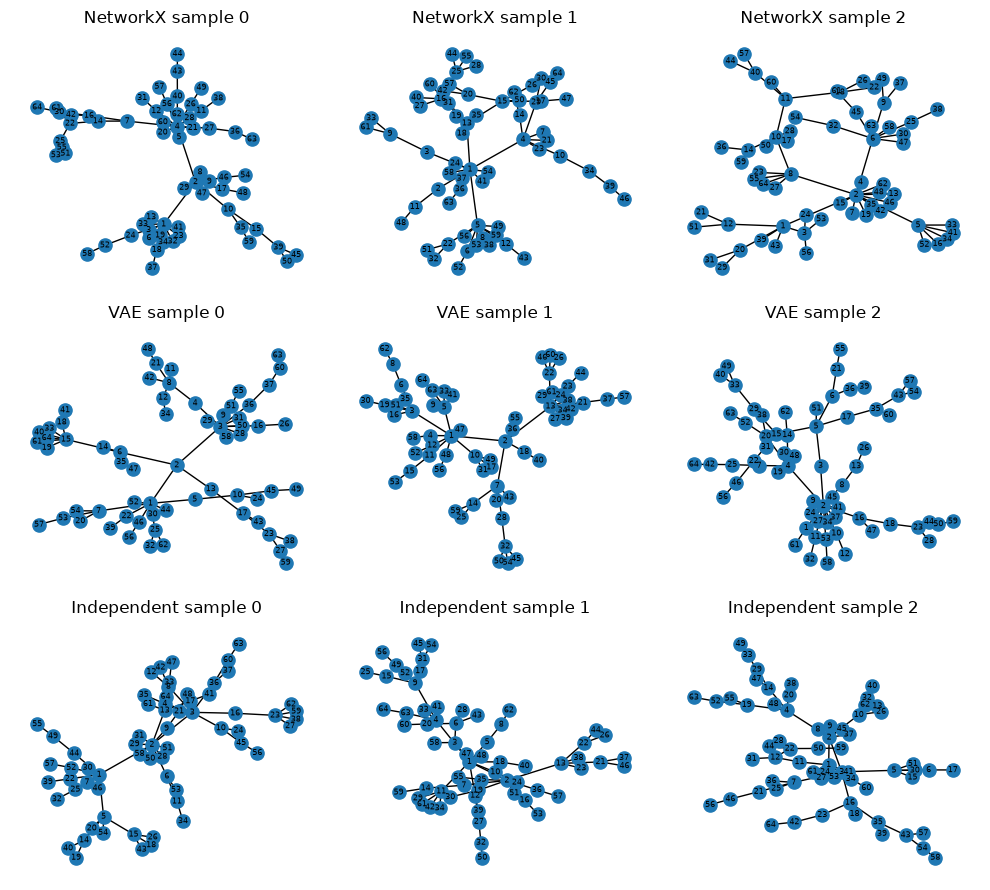

In [6]:
collections = graph_samples_experiment(
    run, generators["vae"], generators["independent"]
)

Hub/leaf summary: {
  "NetworkX": {
    "max_degree_mean": 14.8525390625,
    "max_degree_sd": 4.396772420219343,
    "leaf_fraction_mean": 0.6559219360351562,
    "leaf_fraction_sd": 0.0412165146259532
  },
  "VAE": {
    "max_degree_mean": 14.82568359375,
    "max_degree_sd": 4.492341039277268,
    "leaf_fraction_mean": 0.6246414184570312,
    "leaf_fraction_sd": 0.04637737790681645
  },
  "Independent": {
    "max_degree_mean": 10.68310546875,
    "max_degree_sd": 1.9876678231762115,
    "leaf_fraction_mean": 0.5910186767578125,
    "leaf_fraction_sd": 0.03813813784536002
  }
}


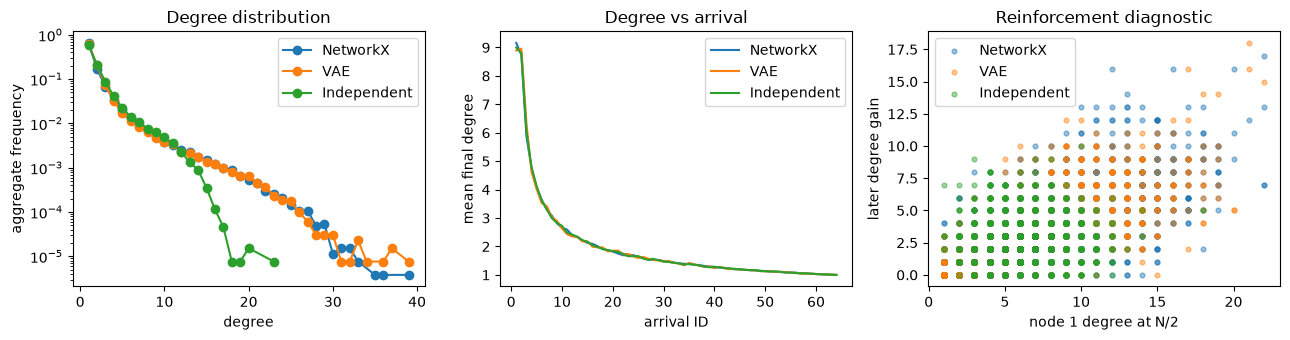

Reinforcement: {
  "NetworkX": {
    "pearson": 0.7076557006858957,
    "bootstrap_95pct": [
      0.6898471333084009,
      0.7228433664709281
    ],
    "undefined_resamples": 0
  },
  "VAE": {
    "pearson": 0.700425761837306,
    "bootstrap_95pct": [
      0.6782697208554981,
      0.726701441785255
    ],
    "undefined_resamples": 0
  },
  "Independent": {
    "pearson": 0.001907798422769757,
    "bootstrap_95pct": [
      -0.04187026756991979,
      0.048827628728702444
    ],
    "undefined_resamples": 0
  }
}


In [7]:
statistics = graph_statistics_experiment(
    collections, num_nodes=config.num_nodes
)

In [8]:
timings = timing_experiment(
    generators["vae"], num_nodes=config.num_nodes, threads=config.threads
)

{'median_scalar_query_ms_including_latent': np.float64(0.08520150004187599), 'median_public_full_graph_ms': np.float64(5.0016104978567455), 'mean_networkx_full_graph_ms': 0.17331350027234294, 'timing_environment': {'device': 'cpu float32 public decoder', 'num_nodes': 64, 'threads': 8}}


In [9]:
structural_invariants = structural_invariants_experiment(
    collections, num_nodes=config.num_nodes
)

Structural invariants (m=1)
collection             graphs   passed   failed
NetworkX                 4096     4096        0
VAE                      2048     2048        0
Independent              2048     2048        0


## Evaluation plan

Run each experiment independently below. Plots display by default. These cells reuse the trained model and graph collections above. See [the evaluation guide](../docs/evaluation-api.md) for statistical conventions and result fields.

The evaluation sample cap and bootstrap count below keep the first pass manageable; increase them for final measurements.

In [10]:
from dataclasses import replace
from svae import evaluate as ev

EVALUATION_GRAPHS = 256
BOOTSTRAP_SAMPLES = 200
LATENT_SAMPLES = 100
SAMPLES_PER_LATENT = 50

evaluation_collections = {
    name: graphs[:EVALUATION_GRAPHS] for name, graphs in collections.items()
}
early_nodes = tuple(range(1, min(10, config.num_nodes) + 1))
evaluation_seeds = range(5_000_000, 5_000_000 + EVALUATION_GRAPHS)
latent_seeds = range(6_000_000, 6_000_000 + LATENT_SAMPLES)

## 2. Exact BA attachment law

Compare the NetworkX reference, categorical VAE, and independent baseline. Compare score distributions rather than treating higher BA likelihood alone as better.

NetworkX {'mean': -183.06396337606157, 'median': -184.34905089077915, 'sd': 9.296043335632511, 'quantiles': array([-198.31708935, -189.25435057, -177.33245028, -162.51624248])}
VAE {'mean': -184.6037992023514, 'median': -185.9817025562416, 'sd': 10.23644631873998, 'quantiles': array([-200.70105656, -192.11259477, -179.00785611, -163.17372393])}
Independent {'mean': -195.98731652760088, 'median': -196.22711921950383, 'sd': 4.9879682068876035, 'quantiles': array([-205.22883982, -199.5403656 , -192.70836378, -186.31159025])}


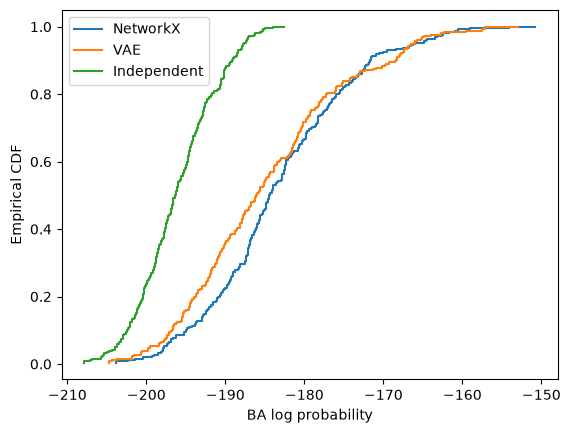

In [11]:
evaluation_collections.pop("Argmax", None)  # Also clear it from an existing kernel session.

ba_likelihood = ev.ba_sequence_likelihood_experiment(evaluation_collections)

NetworkX alpha: 0.9750000000000001 95% interval: [0.975 1.   ]
VAE alpha: 0.9500000000000001 95% interval: [0.925 0.975]
Independent alpha: 0.7000000000000001 95% interval: [0.675 0.725]


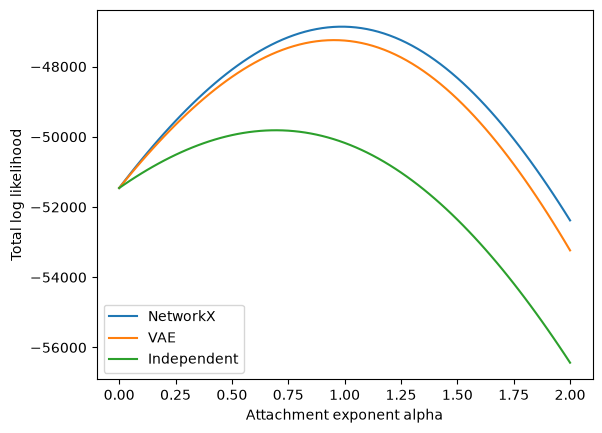

In [12]:
attachment_kernel = ev.attachment_kernel_experiment(
    evaluation_collections, bootstrap_samples=BOOTSTRAP_SAMPLES
)

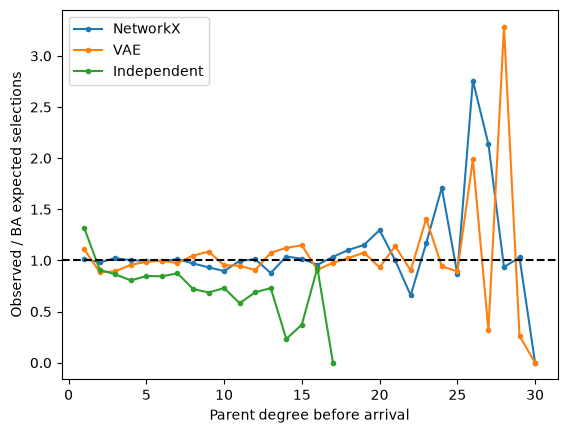

In [13]:
selected_parent_degree = ev.selected_parent_degree_experiment(evaluation_collections)

## 3. Degree distributions and exact finite-size expectations

NetworkX TV: 0.0 tail mass: {5: 0.07635498046875, 10: 0.02117919921875}
VAE TV: 0.0396728515625 tail mass: {5: 0.06878662109375, 10: 0.0216064453125}
Independent TV: 0.0736083984375 tail mass: {5: 0.074951171875, 10: 0.01239013671875}


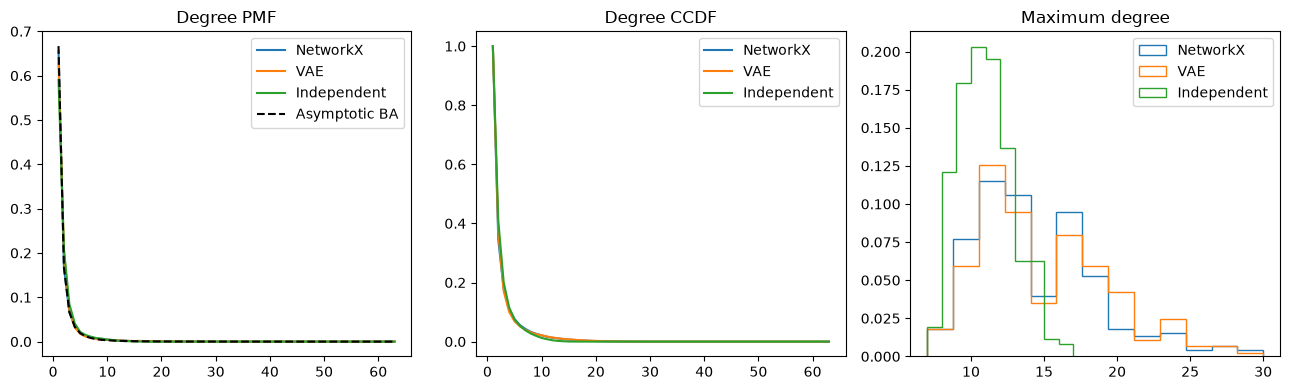

In [14]:
degree_distribution = ev.degree_distribution_experiment(evaluation_collections)

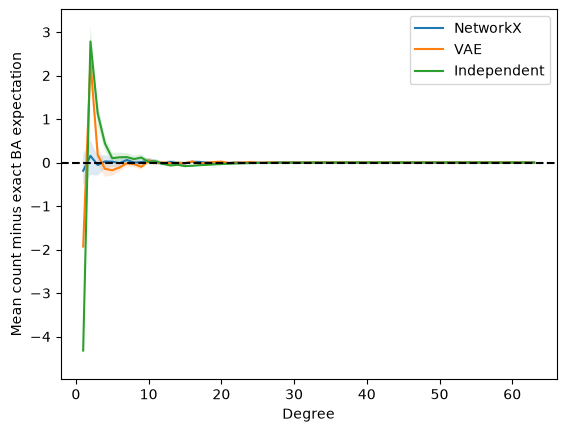

In [15]:
finite_size_counts = ev.finite_size_degree_counts_experiment(
    evaluation_collections,
    num_nodes=config.num_nodes,
    bootstrap_samples=BOOTSTRAP_SAMPLES,
)

## 4. Degree growth by arrival age

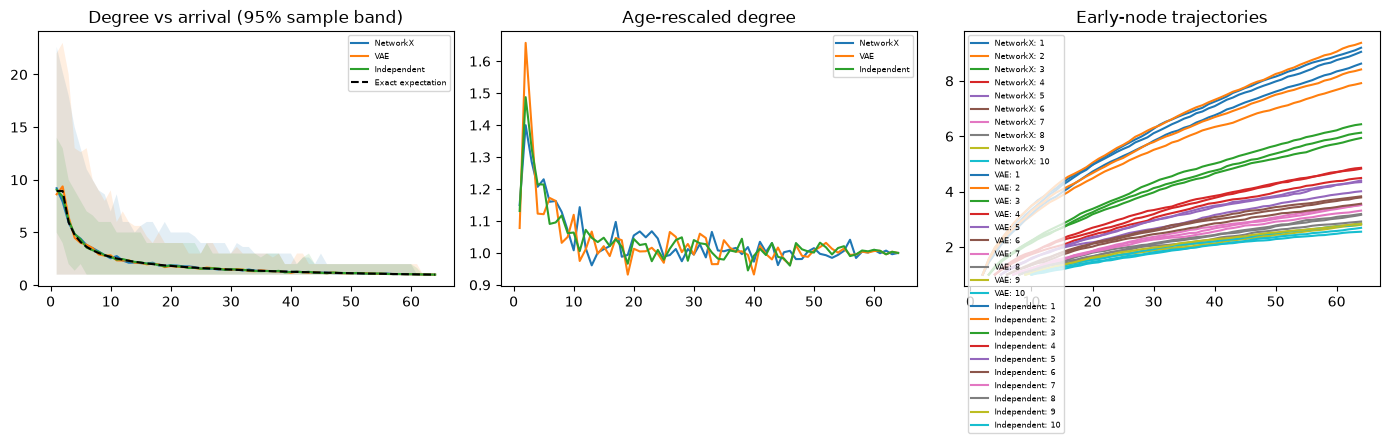

In [16]:
degree_by_age = ev.degree_by_age_experiment(
    evaluation_collections, early_nodes=len(early_nodes)
)

## 5. Reinforcement and temporal dependence

Unborn nodes and constant-degree correlations are undefined; these appear as missing values. Conditional-growth plots mark sparse bins.

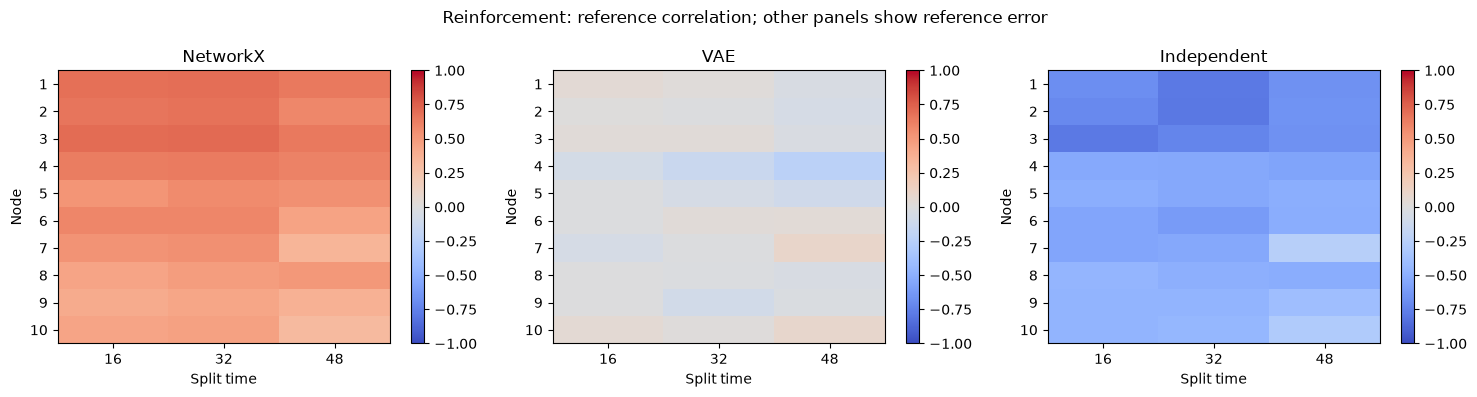

In [17]:
reinforcement = ev.reinforcement_experiment(
    evaluation_collections,
    node_ids=early_nodes,
    bootstrap_samples=BOOTSTRAP_SAMPLES,
)

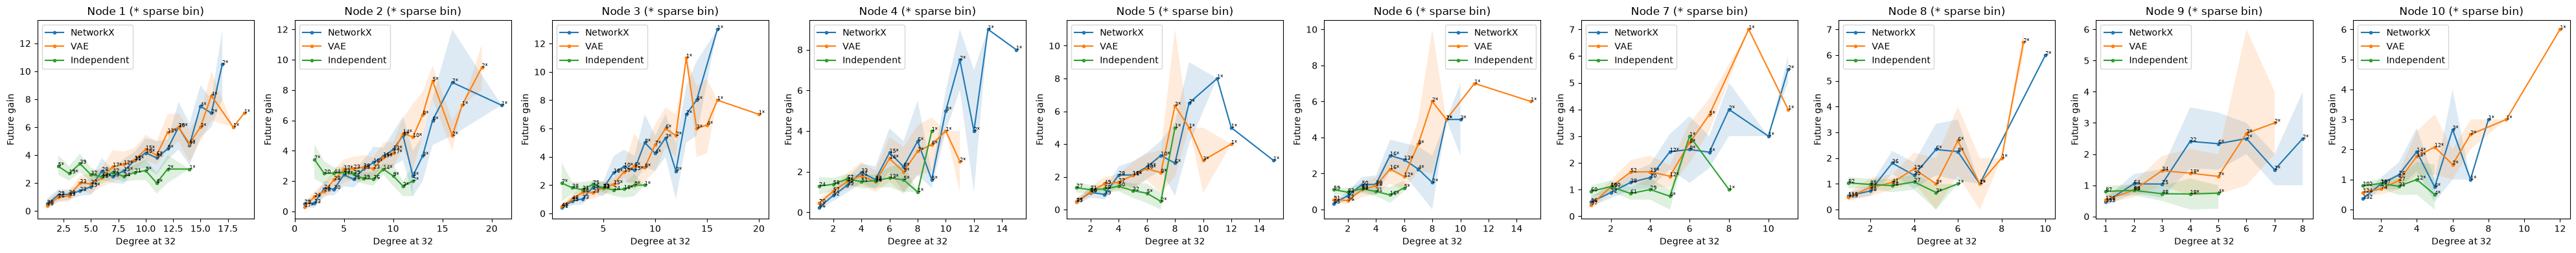

In [18]:
conditional_growth = ev.conditional_future_growth_experiment(
    evaluation_collections,
    node_ids=early_nodes,
    bootstrap_samples=BOOTSTRAP_SAMPLES,
)

Lag-one residual correlations: {'NetworkX': -0.0018138866125801932, 'VAE': -0.004565663162283097, 'Independent': -0.01647477006852084}


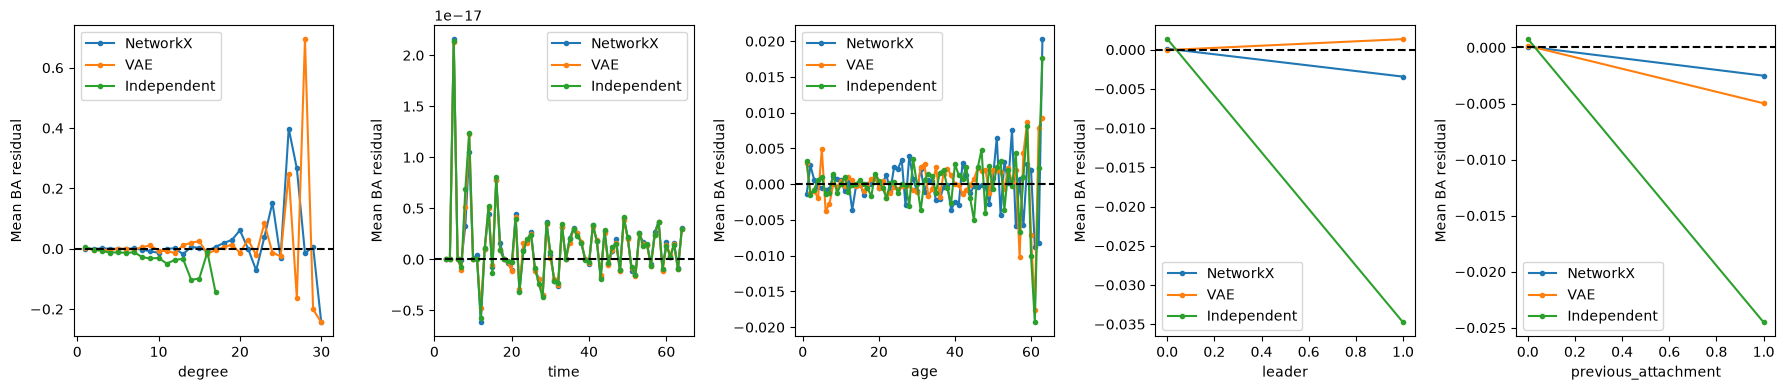

In [19]:
attachment_residuals = ev.attachment_residuals_experiment(evaluation_collections)

## 6. Hub formation and persistence

NetworkX leader persistence: 0.81640625
VAE leader persistence: 0.83984375
Independent leader persistence: 0.78515625


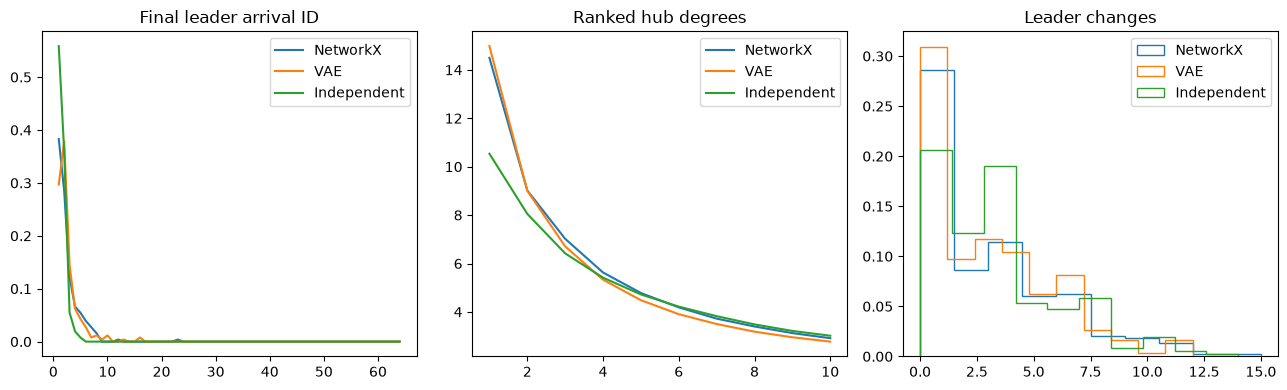

In [20]:
hub_dynamics = ev.hub_dynamics_experiment(evaluation_collections)

## 7. Dependencies beyond node 1

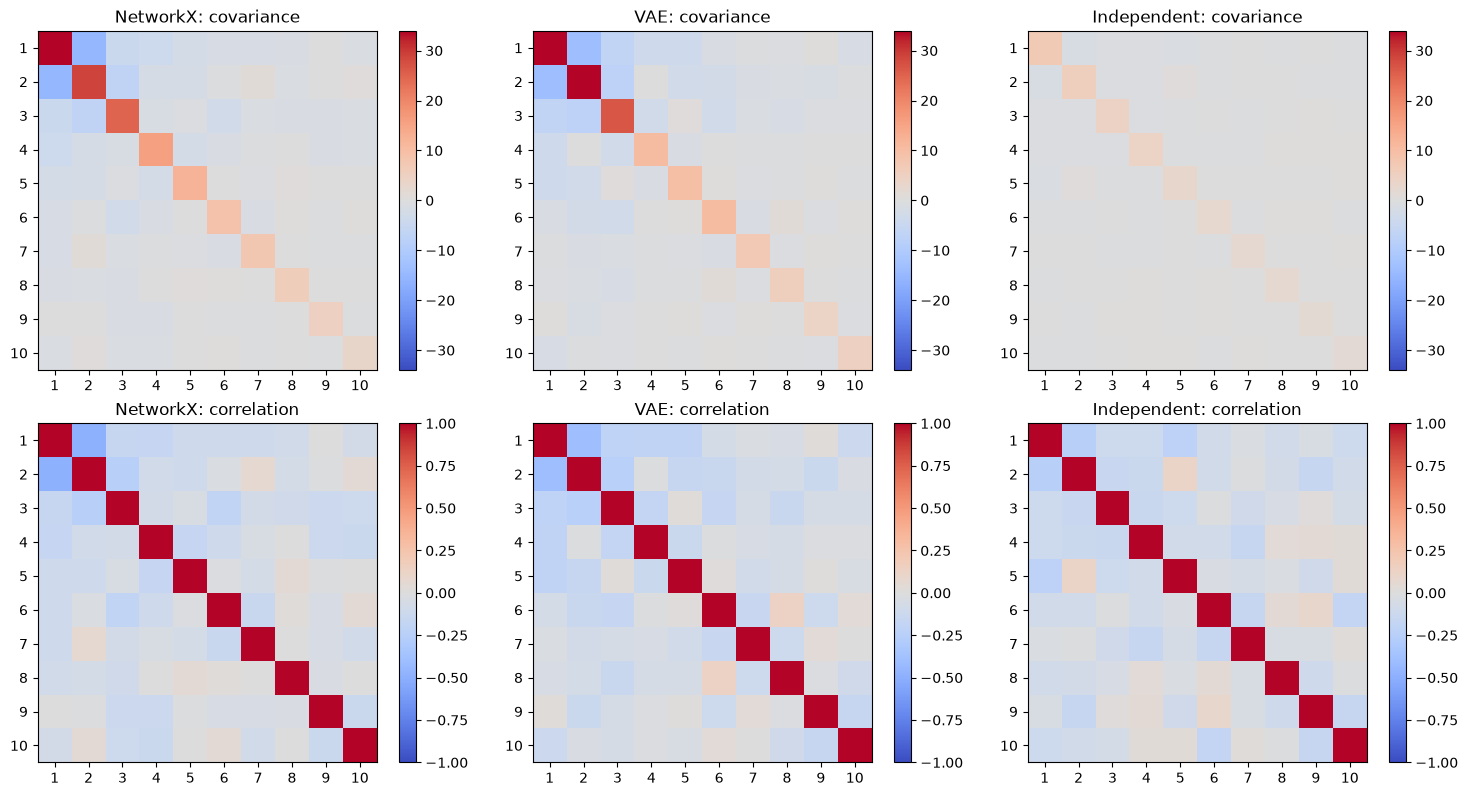

In [21]:
early_covariance = ev.early_node_covariance_experiment(
    evaluation_collections,
    node_ids=early_nodes,
    bootstrap_samples=BOOTSTRAP_SAMPLES,
)

NetworkX {(32, 64, 1): {'ratio': np.float64(1.9047619047619047), 'joint_count': 5, 'marginal_counts': array([28, 24]), 'reliable': False, 'interval': array([0.74125604, 3.71897861])}, (32, 64, 2): {'ratio': np.float64(1.9692307692307693), 'joint_count': 2, 'marginal_counts': array([20, 13]), 'reliable': False, 'interval': array([0.        , 4.48394203])}, (32, 64, 3): {'ratio': np.float64(2.8444444444444446), 'joint_count': 2, 'marginal_counts': array([15, 12]), 'reliable': False, 'interval': array([0.        , 7.27552448])}, (32, 64, 4): {'ratio': np.float64(4.266666666666667), 'joint_count': 2, 'marginal_counts': array([12, 10]), 'reliable': False, 'interval': array([0.        , 9.49542484])}, (32, 64, 5): {'ratio': np.float64(2.3703703703703702), 'joint_count': 1, 'marginal_counts': array([ 9, 12]), 'reliable': False, 'interval': array([0.        , 8.13714286])}}
VAE {(32, 64, 1): {'ratio': np.float64(2.56), 'joint_count': 6, 'marginal_counts': array([30, 20]), 'reliable': False, 'i

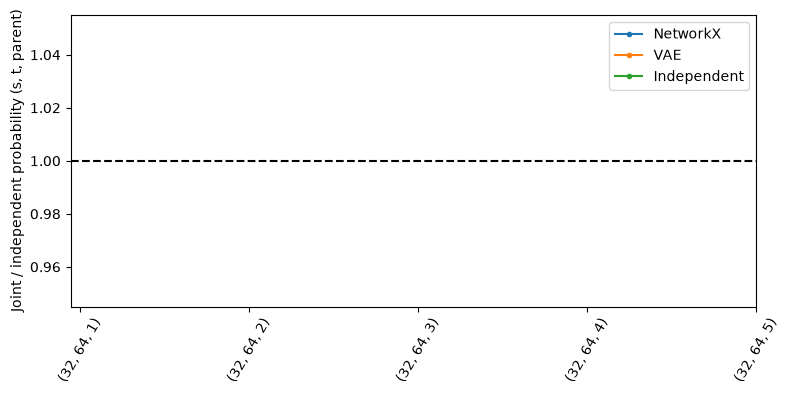

In [22]:
first_arrival = max(3, config.num_nodes // 2)
second_arrival = config.num_nodes
joint_attachments = ev.joint_attachment_experiment(
    evaluation_collections,
    arrival_pairs=[(first_arrival, second_arrival)],
    candidate_parents=tuple(range(1, min(5, first_arrival - 1) + 1)),
    bootstrap_samples=BOOTSTRAP_SAMPLES,
)

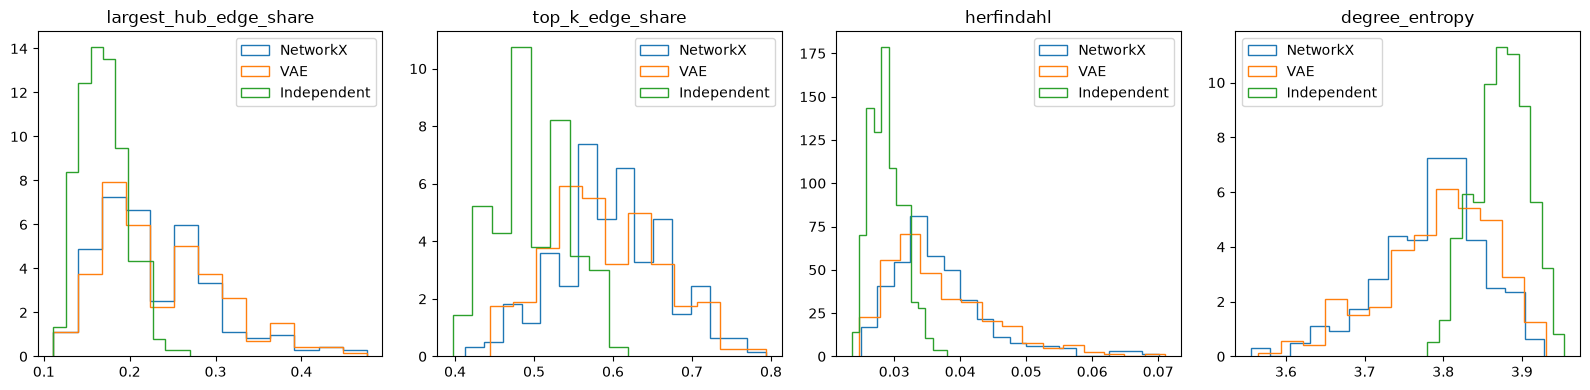

In [23]:
hub_concentration = ev.hub_concentration_experiment(evaluation_collections)

## 8. Tree geometry

NetworkX geometry Wasserstein: {'mean_depth': 0.0, 'max_depth': 0.0, 'diameter': 0.0, 'radius': 0.0, 'branch_count': 0.0, 'largest_branch_fraction': 0.0, 'branch_balance': 0.0}
VAE geometry Wasserstein: {'mean_depth': 0.04815673828125, 'max_depth': 0.078125, 'diameter': 0.14453125, 'radius': 0.06640625, 'branch_count': 0.62890625, 'largest_branch_fraction': 0.03025793650793651, 'branch_balance': 0.03369477925770338}
Independent geometry Wasserstein: {'mean_depth': 0.120849609375, 'max_depth': 0.30859375, 'diameter': 0.8125, 'radius': 0.40625, 'branch_count': 2.6171875, 'largest_branch_fraction': 0.08079117063492063, 'branch_balance': 0.0633295567344472}


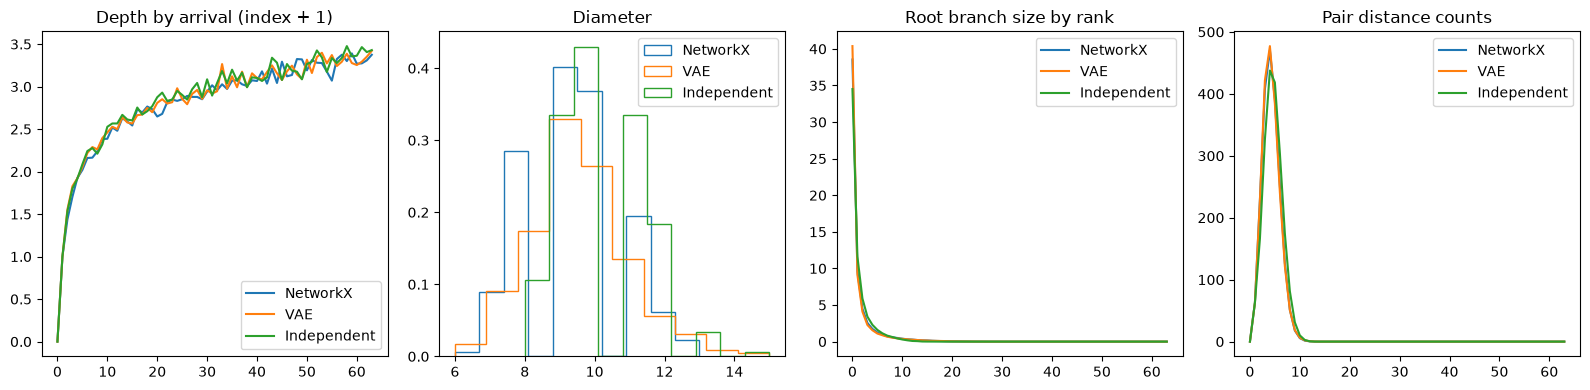

In [24]:
tree_geometry = ev.tree_geometry_experiment(evaluation_collections)

## 9. Degree correlations along edges

NetworkX assortativity: [-0.3335689  -0.25099602 -0.30828596 -0.296125   -0.32359273 -0.46291885
 -0.26629488 -0.20311312 -0.36446105 -0.2785409  -0.14540907 -0.31309711
 -0.20750888 -0.32254084 -0.25116963 -0.29932196 -0.26515396 -0.31184182
 -0.17920065 -0.35948634 -0.27646879 -0.33002081 -0.24867905 -0.22747277
 -0.30749176 -0.32120808 -0.21600567 -0.23823257 -0.22212055 -0.4059088
 -0.20388503 -0.27612637 -0.26459622 -0.35728477 -0.26326655 -0.35344809
 -0.23136759 -0.38032819 -0.31281329 -0.21887664 -0.28605313 -0.26048804
 -0.24091038 -0.15167453 -0.24430709 -0.26588757 -0.30897538 -0.22569244
 -0.2520031  -0.30767794 -0.15284877 -0.26508375 -0.28646728 -0.31790852
 -0.21809849 -0.27172877 -0.27087393 -0.30766296 -0.15144173 -0.26382704
 -0.29523539 -0.42008926 -0.30830946 -0.30446366 -0.28174873 -0.44797729
 -0.30872715 -0.30375042 -0.33836826 -0.28562705 -0.29237288 -0.26712847
 -0.34396134 -0.26991324 -0.34514925 -0.30522262 -0.28294583 -0.25063949
 -0.31797779 -0.28138075 -0.

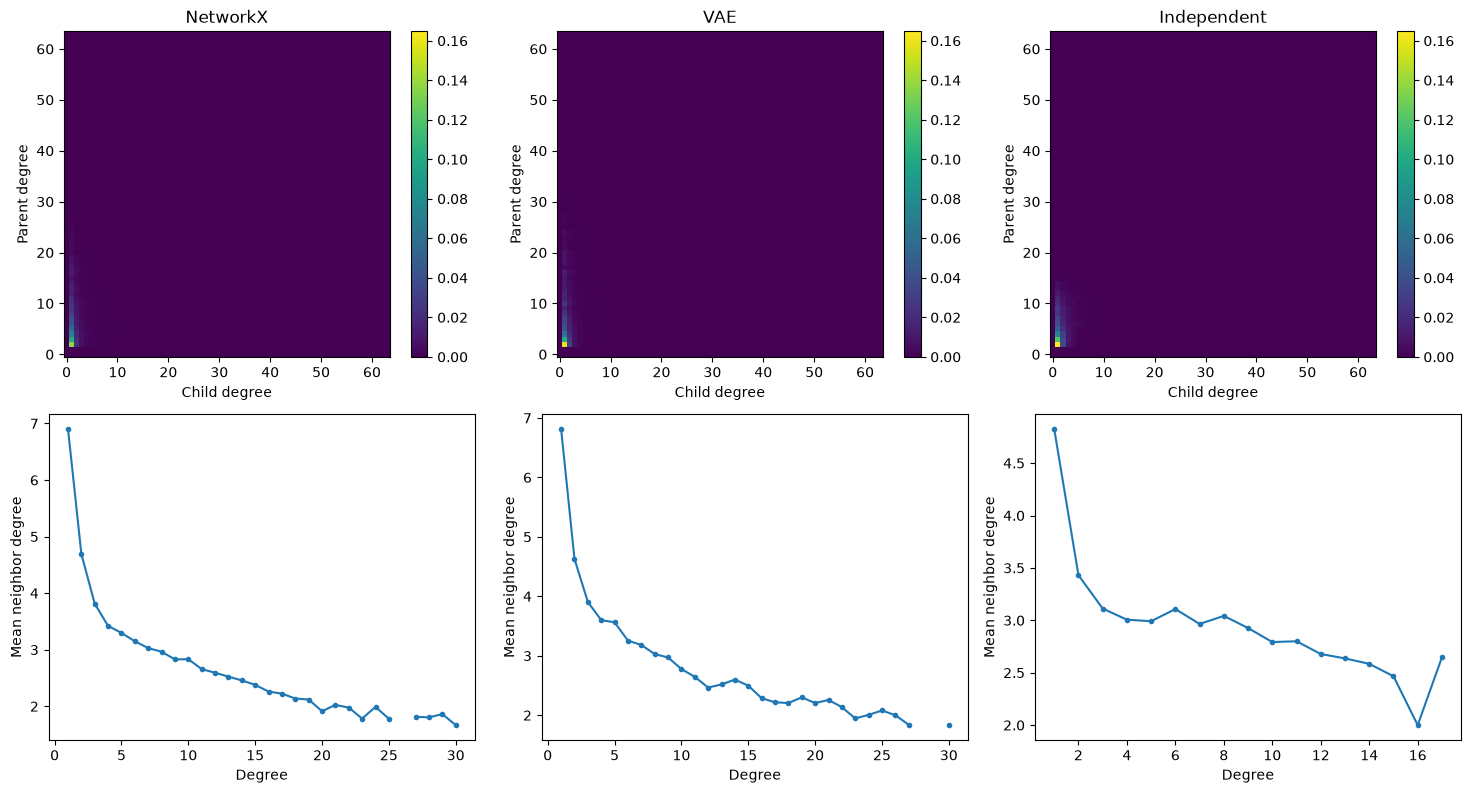

In [25]:
edge_correlations = ev.edge_degree_correlation_experiment(evaluation_collections)

## 10. Latent diagnostics

The ablation cell generates `LATENT_SAMPLES × SAMPLES_PER_LATENT` replicate graphs, plus comparison collections. Whole-latent shuffling preserves sharing within each graph; it is a seed reassignment control. Probes use fresh prior latent/generated-graph pairs with a held-out split.

Hub/leaf summary: {
  "Normal": {
    "max_degree_mean": 14.56,
    "max_degree_sd": 4.488638856922974,
    "leaf_fraction_mean": 0.62,
    "leaf_fraction_sd": 0.04112335164483861
  },
  "Zero": {
    "max_degree_mean": 11.48,
    "max_degree_sd": 1.997372010791918,
    "leaf_fraction_mean": 0.57875,
    "leaf_fraction_sd": 0.038588986103354005
  },
  "Shuffled": {
    "max_degree_mean": 14.83,
    "max_degree_sd": 4.348586209356096,
    "leaf_fraction_mean": 0.6178125,
    "leaf_fraction_sd": 0.04765346851876248
  },
  "Averaged": {
    "max_degree_mean": 10.75,
    "max_degree_sd": 1.8768929838238708,
    "leaf_fraction_mean": 0.58875,
    "leaf_fraction_sd": 0.03728632304697845
  },
  "Independent": {
    "max_degree_mean": 10.91,
    "max_degree_sd": 1.980179565370553,
    "leaf_fraction_mean": 0.59015625,
    "leaf_fraction_sd": 0.0378752661715153
  }
}


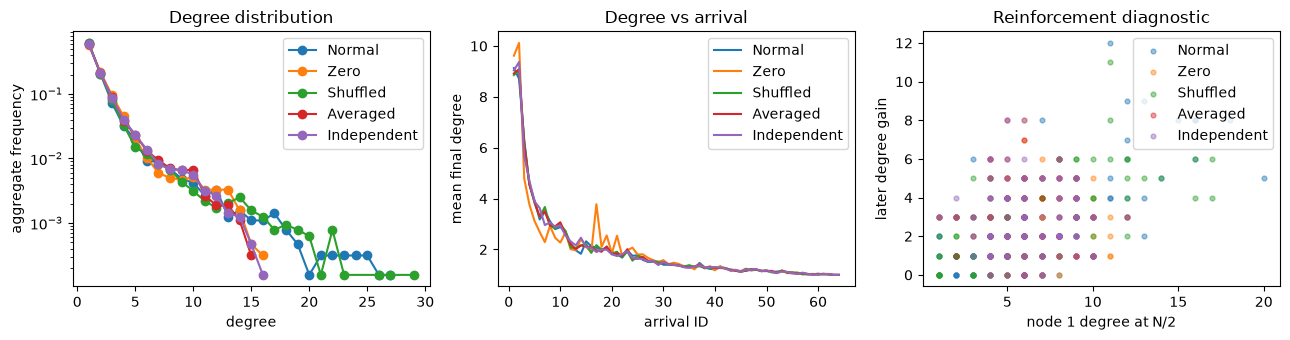

Reinforcement: {
  "Normal": {
    "pearson": 0.6490898816518048,
    "bootstrap_95pct": [
      0.5376053459719194,
      0.731759489200311
    ],
    "undefined_resamples": 0
  },
  "Zero": {
    "pearson": -0.015155574293399456,
    "bootstrap_95pct": [
      -0.15319885995270616,
      0.13272320459068124
    ],
    "undefined_resamples": 0
  },
  "Shuffled": {
    "pearson": 0.6369330042270831,
    "bootstrap_95pct": [
      0.5555683768644168,
      0.7238067844873519
    ],
    "undefined_resamples": 0
  },
  "Averaged": {
    "pearson": 0.032124004658863926,
    "bootstrap_95pct": [
      -0.11252946447993034,
      0.20085722976260784
    ],
    "undefined_resamples": 0
  },
  "Independent": {
    "pearson": 0.017837972235139554,
    "bootstrap_95pct": [
      -0.1432596371979503,
      0.1889410370268516
    ],
    "undefined_resamples": 0
  }
}


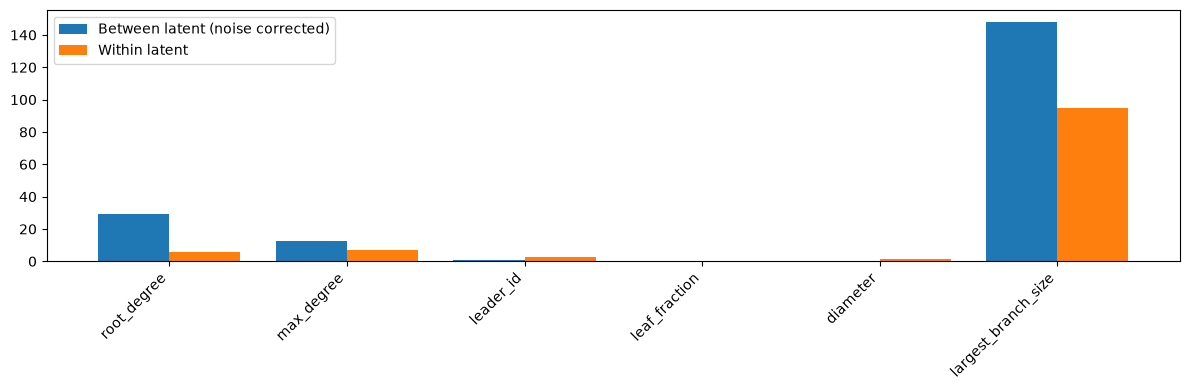

In [26]:
latent_ablation = ev.latent_ablation_experiment(
    generators["vae"],
    seeds=latent_seeds,
    samples_per_latent=SAMPLES_PER_LATENT,
    baseline=generators["independent"],
)

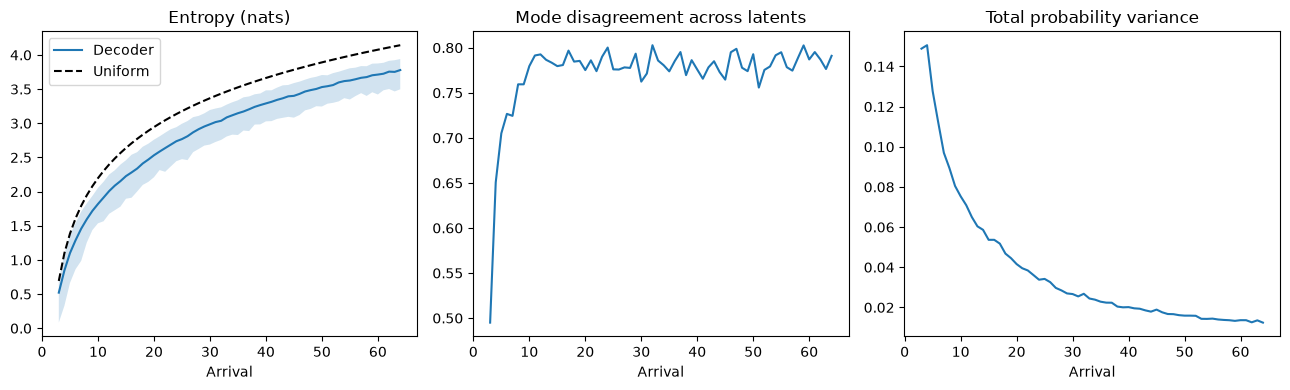

In [27]:
decoder_entropy = ev.decoder_entropy_experiment(
    generators["vae"], seeds=latent_seeds
)

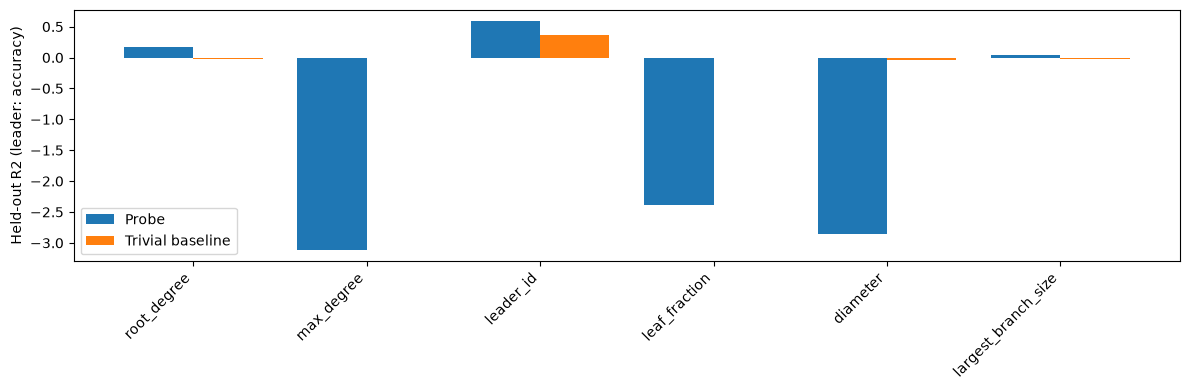

In [28]:
latent_probes = ev.latent_predictability_experiment(
    run, seeds=evaluation_seeds
)

## 11. Distribution-level comparisons

The classifier uses held-out folds. Coverage and diversity refer to the documented graph-feature representation.

VAE {'energy_distance_squared': 0.15189070294996565, 'coverage': 0.4375, 'precision': 0.625, 'duplicate_rate': 0.0, 'leader_total_variation': 0.14453125}
Independent {'energy_distance_squared': 1.2053712693764633, 'coverage': 0.25, 'precision': 0.65625, 'duplicate_rate': 0.0, 'leader_total_variation': 0.25}


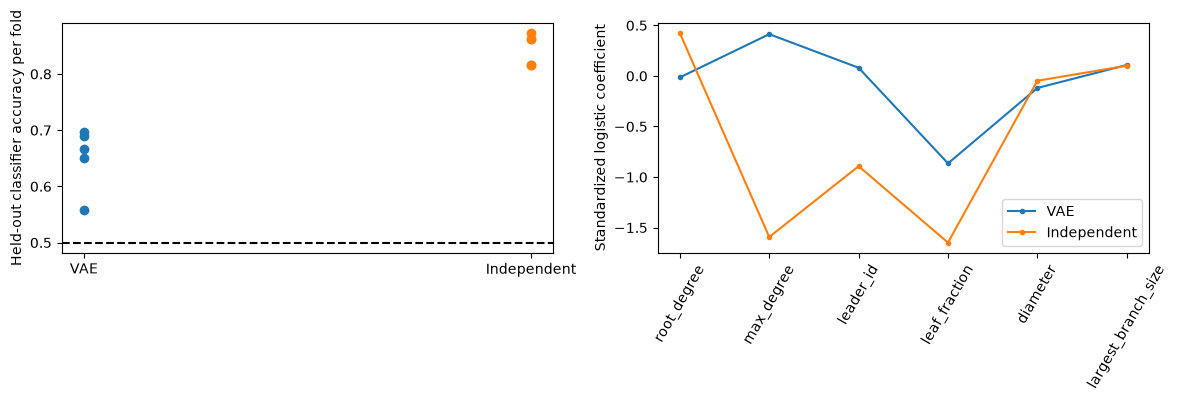

In [29]:
distribution_comparison = ev.distribution_comparison_experiment(
    evaluation_collections, cross_validation_folds=5
)

## 12. Scaling across graph size, latent width, and training seed

**This cell trains new models.** The default is a small smoke-profile sweep: two graph sizes × two latent widths × two training seeds = eight short runs. Use the demo or large profile and expand these settings for scientific measurements. Smoke training is only a workflow check; it is not enough to judge capacity scaling.

N=16, D=4, seed=11: {'ba_wasserstein': 0.31029234855232135, 'reinforcement_rmse': 0.4760857090593718, 'degree_tv': 0.2080078125, 'hub_wasserstein': 2.21875, 'leader_tv': 0.15625, 'diameter_wasserstein': 1.921875, 'kl_per_graph': 0.006700722500681877, 'parameters': 25624, 'decoder_parameters': 6544, 'output_head_multiply_adds': 1024, 'duplicate_rate': 0.0, 'query_ms': np.float64(0.06519250018754974), 'graph_ms': np.float64(0.9415669992449693)}
N=16, D=4, seed=22: {'ba_wasserstein': 0.3021619680695439, 'reinforcement_rmse': 0.44242570316222835, 'degree_tv': 0.2021484375, 'hub_wasserstein': 2.125, 'leader_tv': 0.140625, 'diameter_wasserstein': 1.890625, 'kl_per_graph': 0.002880275947973132, 'parameters': 25624, 'decoder_parameters': 6544, 'output_head_multiply_adds': 1024, 'duplicate_rate': 0.0, 'query_ms': np.float64(0.0648775021545589), 'graph_ms': np.float64(0.9402239993505646)}
N=16, D=8, seed=11: {'ba_wasserstein': 0.29703613362089487, 'reinforcement_rmse': 0.45942773171492185, 'degr

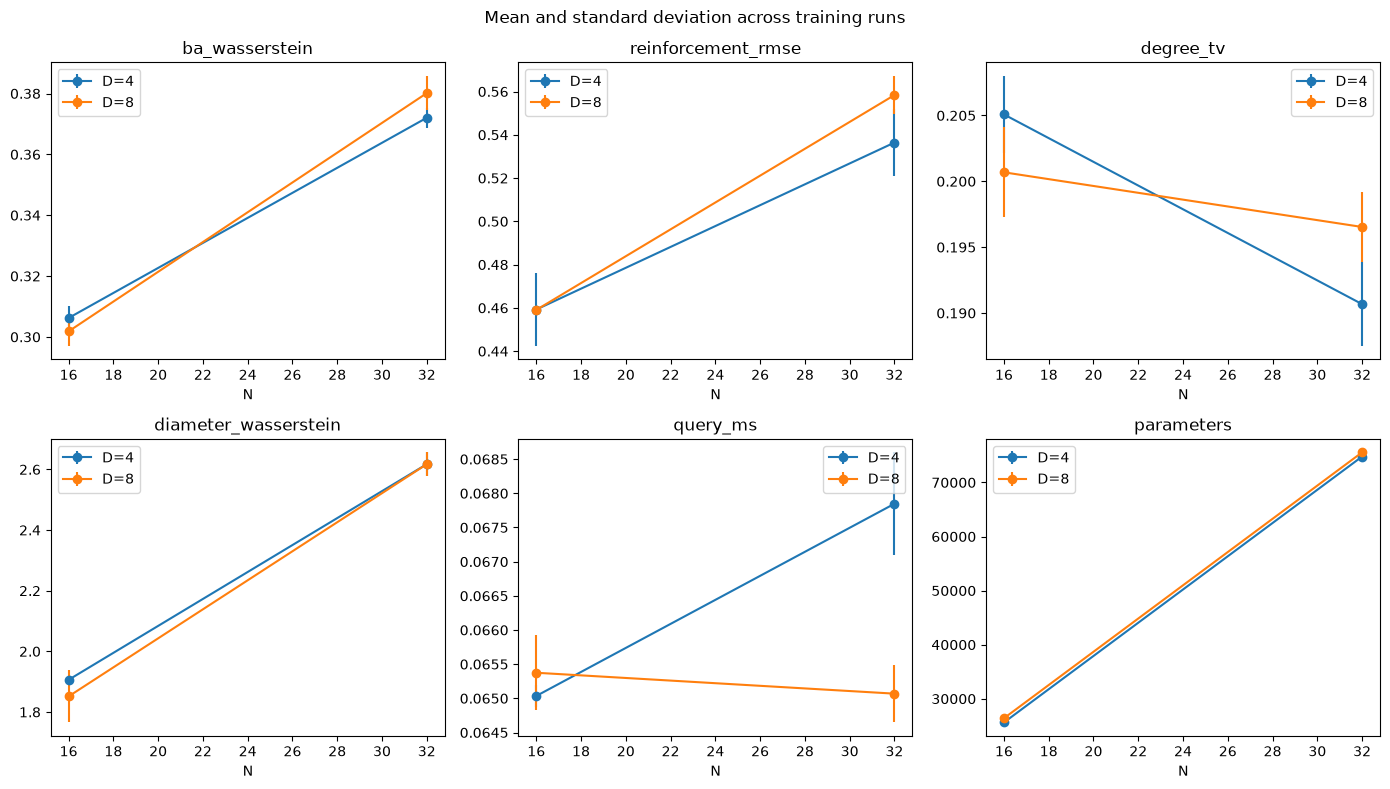

In [30]:
SCALING_PROFILE = "smoke"
SCALING_GRAPH_SIZES = (16, 32)
SCALING_LATENT_DIMS = (4, 8)
SCALING_TRAINING_SEEDS = (11, 22)

scaling_configs = [
    replace(PROFILES[SCALING_PROFILE], num_nodes=n, latent_dim=d)
    for n in SCALING_GRAPH_SIZES
    for d in SCALING_LATENT_DIMS
]
scaling_results = ev.scaling_experiment(
    scaling_configs,
    training_seeds=SCALING_TRAINING_SEEDS,
    bootstrap_samples=BOOTSTRAP_SAMPLES,
)